In [52]:
import numpy as np
import pandas as pd
import matplotlib
import torch
import torchvision

In [53]:
print(np.__version__)
print(pd.__version__)
print(matplotlib.__version__)
print(torch.__version__)
print(torchvision.__version__)

2.4.4
3.0.3
3.11.0
2.13.0
0.28.0


In [54]:
from  pathlib import Path

In [55]:
def count_jpeg(kind , disease):
    path = Path(f"./data/{kind}/{disease}/")
    count = sum (1 for p in path.iterdir() if p.is_file())
    return count

In [56]:
train_NORMAL_count = count_jpeg("train" , "NORMAL")
train_NORMAL_count

1341

In [57]:
train_PNEUMONIA_count = count_jpeg("train" , "PNEUMONIA")
train_PNEUMONIA_count

3875

In [58]:
test_NORMAL_count = count_jpeg("test" , "NORMAL")
test_NORMAL_count

234

In [59]:
test_PNEUMONIA_count = count_jpeg("test" , "PNEUMONIA")
test_PNEUMONIA_count

390

In [60]:
val_PNEUMONIA_count = count_jpeg("val" , "PNEUMONIA")
val_PNEUMONIA_count

8

In [61]:
val_NORMAL_count = count_jpeg("val" , "NORMAL")
val_NORMAL_count

8

In [62]:
NORMAL_compair = train_NORMAL_count / train_PNEUMONIA_count
NORMAL_compair

0.3460645161290323

In [63]:
test_compair = test_NORMAL_count / test_PNEUMONIA_count

test_compair

0.6

In [64]:
val_compair = val_NORMAL_count / val_PNEUMONIA_count
val_compair

1.0

In [65]:
values = [train_NORMAL_count , train_PNEUMONIA_count , test_NORMAL_count , test_PNEUMONIA_count , val_NORMAL_count, val_PNEUMONIA_count]
  


In [66]:
labels = ["train_NORMAL" , "train_PNEUMONIA" , "test_NORMAL" , "test_PNEUMONIA" , "val_NORMAL" , "val_PNEMONIA"]

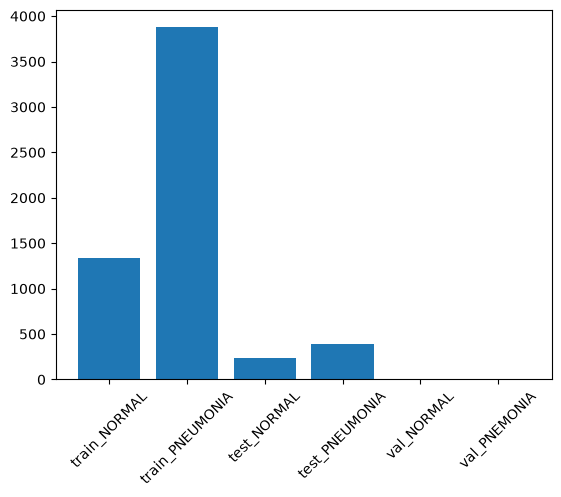

In [67]:
import matplotlib.pyplot as plt
plt.bar(labels,values)
plt.xticks(rotation= 45)
plt.show()

In [68]:
from PIL import Image

In [69]:
train_NORMAL_path = Path("./data/train/NORMAL/")

In [70]:
with Image.open( "./data/train/NORMAL/IM-0115-0001.jpeg") as img:
    width , height = img.size
    print(f"width :{width}",
    f"height :{height}")

width :2090 height :1858


In [112]:
widths = []
heights = []
for p in Path.iterdir(train_NORMAL_path):
    if p.is_file():
        with Image.open(p) as image:
            width  , height= image.size
            widths.append(width)
            heights.append(height)


In [72]:
print(len(widths))

print(len(heights))

1341
1341


In [73]:
print(f"mean:{np.mean(widths)}")
print(f"std:{np.std(widths)}")
print(f"min:{np.min(widths)}")
print(f"max:{np.max(widths)}")

mean:1667.7345264727815
std:289.10265844957775
min:912
max:2916


In [85]:
def get_data(kind,species):
    widths = []
    heights = []
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            with Image.open(p) as image:
                width  , height= image.size
                widths.append(width)
                heights.append(height)
    return widths , heights

def get_statics_value(value):
    mean_value = np.mean(value)
    std_value = np.std(value)
    max_value = np.max(value)
    min_value = np.min(value)
    return dict([( "mean" ,mean_value), ( "std" ,std_value ), ( "max" ,max_value) , ("min" ,min_value)])

In [92]:
NORMAL_train_w , NORMAL_train_h = get_data("train", "NORMAL")
NORMAL_train_w_values= get_statics_value(NORMAL_train_w)
NORMAL_train_w_values

{'mean': np.float64(1667.7345264727815),
 'std': np.float64(289.10265844957775),
 'max': np.int64(2916),
 'min': np.int64(912)}

In [93]:
NORMAL_train_h_values = get_statics_value(NORMAL_train_h)
NORMAL_train_h_values

{'mean': np.float64(1381.4310216256524),
 'std': np.float64(326.19904080232703),
 'max': np.int64(2663),
 'min': np.int64(672)}

In [94]:
PNEUMONIA_train_w , PNEUMONIA_train_h = get_data("train", "PNEUMONIA")
PNEUMONIA_train_w_values= get_statics_value(PNEUMONIA_train_w)
PNEUMONIA_train_w_values

{'mean': np.float64(1200.4836129032258),
 'std': np.float64(291.26808567274077),
 'max': np.int64(2772),
 'min': np.int64(384)}

In [96]:
PNEUMONIA_train_h_values= get_statics_value(PNEUMONIA_train_h)
PNEUMONIA_train_h_values

{'mean': np.float64(825.0268387096775),
 'std': np.float64(277.0380047103235),
 'max': np.int64(2304),
 'min': np.int64(127)}

In [97]:
NORMAL_val_w , NORMAL_val_h = get_data("val", "NORMAL")
NORMAL_val_w_values = get_statics_value(NORMAL_val_w)
NORMAL_val_w_values

{'mean': np.float64(1479.5),
 'std': np.float64(207.4072081678937),
 'max': np.int64(1776),
 'min': np.int64(1240)}

In [98]:
NORMAL_val_h_values = get_statics_value(NORMAL_val_h)
NORMAL_val_h_values

{'mean': np.float64(1191.875),
 'std': np.float64(166.51909612714093),
 'max': np.int64(1416),
 'min': np.int64(928)}

In [103]:
NORMAL_test_w , NORMAL_test_h = get_data("test", "NORMAL")
NORMAL_test_w_values = get_statics_value(NORMAL_test_w)
NORMAL_test_w_values

{'mean': np.float64(1800.3034188034187),
 'std': np.float64(365.1477365060494),
 'max': np.int64(2752),
 'min': np.int64(984)}

In [104]:
NORMAL_test_h_values = get_statics_value(NORMAL_test_h)
NORMAL_test_h_values

{'mean': np.float64(1369.0897435897436),
 'std': np.float64(428.2607596673719),
 'max': np.int64(2713),
 'min': np.int64(496)}

In [106]:
PNEUMONIA_test_w , PNEUMONIA_test_h = get_data("test", "PNEUMONIA")
PNEUMONIA_test_w_values = get_statics_value(PNEUMONIA_test_w)
PNEUMONIA_test_w_values

{'mean': np.float64(1140.823076923077),
 'std': np.float64(208.59048821829802),
 'max': np.int64(2000),
 'min': np.int64(728)}

In [107]:
PNEUMONIA_test_h_values = get_statics_value(PNEUMONIA_test_h)
PNEUMONIA_test_h_values

{'mean': np.float64(765.2897435897436),
 'std': np.float64(192.84975059631904),
 'max': np.int64(1456),
 'min': np.int64(344)}

In [109]:
PNEUMONIA_val_w , PNEUMONIA_val_h = get_data("val", "PNEUMONIA")
PNEUMONIA_val_w_values = get_statics_value(PNEUMONIA_val_w)
PNEUMONIA_val_w_values

{'mean': np.float64(1217.0),
 'std': np.float64(214.82783804712088),
 'max': np.int64(1664),
 'min': np.int64(968)}

In [111]:
PNEUMONIA_val_h_values = get_statics_value(PNEUMONIA_val_h)
PNEUMONIA_val_h_values

{'mean': np.float64(814.0),
 'std': np.float64(174.71119025408763),
 'max': np.int64(1128),
 'min': np.int64(592)}

In [114]:
df = pd.DataFrame({
    "NORMAL_train_width": NORMAL_train_w_values ,
    "NORMAL_train_height" : NORMAL_train_h_values,
    "PNEUMONIA_train_width" : PNEUMONIA_train_w_values,
    "PNEUMONIA_train_height" : PNEUMONIA_train_h_values,
    "NORMAL_test_width" : NORMAL_test_w_values,
    "NORMAL_test_height" : NORMAL_test_h_values,
    "PNEUMONIA_test_width" : PNEUMONIA_test_w_values,
    "PNEUMONIA_test_height" : PNEUMONIA_test_h_values,
    "NORMAL_val_width" : NORMAL_val_w_values,
    "NORMAL_val_height" : NORMAL_val_h_values,
    "PNEUMONIA_val_width" : PNEUMONIA_val_w_values,
    "PNEUMONIA_val_height" : PNEUMONIA_val_h_values
})

In [117]:
df

,NORMAL_train_width,NORMAL_train_height,PNEUMONIA_train_width,PNEUMONIA_train_height,NORMAL_test_width,NORMAL_test_height,PNEUMONIA_test_width,PNEUMONIA_test_height,NORMAL_val_width,NORMAL_val_height,PNEUMONIA_val_width,PNEUMONIA_val_height
mean,1667.734526,1381.431022,1200.483613,825.026839,1800.303419,1369.089744,1140.823077,765.289744,1479.500000,1191.875000,1217.000000,814.00000
std,289.102658,326.199041,291.268086,277.038005,365.147737,428.260760,208.590488,192.849751,207.407208,166.519096,214.827838,174.71119
max,2916.000000,2663.000000,2772.000000,2304.000000,2752.000000,2713.000000,2000.000000,1456.000000,1776.000000,1416.000000,1664.000000,1128.00000
min,912.000000,672.000000,384.000000,127.000000,984.000000,496.000000,728.000000,344.000000,1240.000000,928.000000,968.000000,592.00000


画面さいずは十分バラついていると見られる。
各画像によってばらつき度合いが変わるので、画像のサイズを統一する必要がありそう。

Image.siz   

In [119]:
from PIL import ImageStat

def is_grayscale(fn):
	im = Image.open(fn).convert("RGB")
	stat = ImageStat.Stat(im)

	if abs(sum(stat.sum)/3 - stat.sum[0]) < (stat.sum[0] * 0.001) :
		return True #yes, grayscale
	else:
		return False #no,  colorimg


is_grayscale("./data/train/NORMAL/IM-0115-0001.jpeg")

True

In [ ]:
def count_grayscale(kind,species):
    count=0
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            if is_grayscale(p) == True:
                count +=1
    return count

In [128]:
NORMAL_train_grayscale= count_grayscale("train", "NORMAL")
NORMAL_train_grayscale

1341

In [129]:
PNEUMONIA_train_grayscale= count_grayscale("train", "PNEUMONIA")

In [130]:
PNEUMONIA_train_grayscale

3875

In [131]:
NORMAL_test_grayscale= count_grayscale("test", "NORMAL")
PNEUMONIA_test_grayscale= count_grayscale("test", "PNEUMONIA")

In [132]:
NORMAL_test_grayscale

234

In [133]:
PNEUMONIA_test_grayscale

390

In [134]:
NORMAL_val_grayscale= count_grayscale("val", "NORMAL")

In [135]:
PNEUMONIA_val_grayscale= count_grayscale("val", "PNEUMONIA")

In [136]:
PNEUMONIA_val_grayscale

8

In [137]:
NORMAL_val_grayscale

8

全画像がグレースケールと一致する。

In [184]:
img = Image.open("./data/train/NORMAL/IM-0115-0001.jpeg")

hist = img.histogram()
print(len(hist))

256


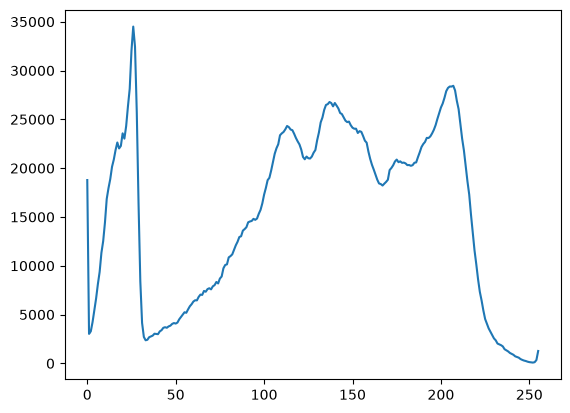

In [165]:
plt.plot(hist)

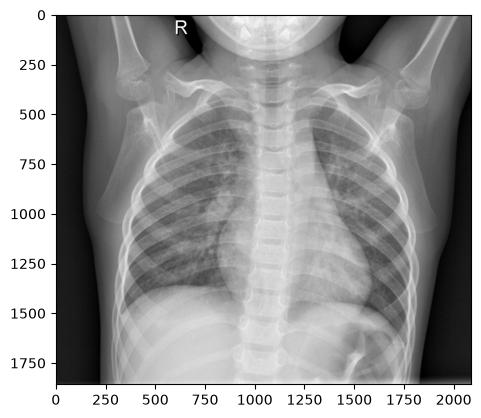

In [236]:
#　訓練用画像の確認
plt.imshow(img,cmap="gray")
plt.show()

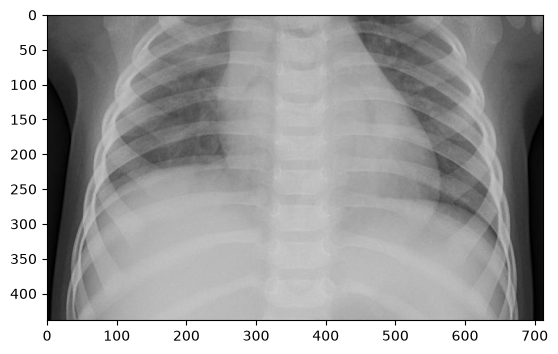

In [237]:
#　テスト用画像の確認
image =Image.open("./data/train/PNEUMONIA/person1_bacteria_1.jpeg")
plt.imshow(image)
plt.show()

In [216]:
def get_piksel(kind,species):
    images = []
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            with Image.open(p) as image:
                image = image.convert("L")
                images.append(image.histogram())
    images = np.asarray(images)
    sum_images = np.sum(images,axis=0)
    mean_images = np.mean(images,axis=0)
    return sum_images ,mean_images

In [217]:
NORMAL_sum_image , NORMAL_mean_image = get_piksel("train" , "NORMAL")

In [218]:
NORMAL_sum_image , NORMAL_mean_image

(array([252899899,   5614167,   3902937,   3721520,   3788648,   3980128,
          4204126,   4362901,   4538699,   4572829,   4471988,   4454904,
          4470904,   4493338,   4475553,   4413839,   4343038,   4299703,
          4267298,   4238483,   4207109,   4191076,   4198282,   4231688,
          4279815,   4324023,   4381947,   4439077,   4524655,   4569591,
          4638100,   4740500,   4813586,   4910813,   5001960,   5087982,
          5167011,   5265512,   5363989,   5480368,   5594843,   5732097,
          5874223,   6037197,   6182054,   6315948,   6466962,   6601411,
          6750580,   6910723,   7065029,   7240736,   7412563,   7592848,
          7766723,   7939107,   8111163,   8285749,   8471487,   8647539,
          8833373,   9023837,   9206870,   9401640,   9585225,   9774210,
          9974236,  10166842,  10368245,  10566359,  10752483,  10936796,
         11130137,  11310159,  11491139,  11668738,  11856730,  12049247,
         12227152,  12403917,  1258689

In [220]:
PNEUMONIA_sum_image , PNEUMONIA_mean_image = get_piksel("train" , "PNEUMONIA")
PNEUMONIA_sum_image , PNEUMONIA_mean_image

(array([178569087,  13988933,  10391909,   8817335,   8675862,   8923483,
          9317886,   9425867,   9279100,   9448398,   9494292,   9563417,
          9365027,   9497330,   9304279,   9422410,   9554367,   9705340,
          9647620,   9653182,   9584704,   9530914,   9426997,   9258256,
          9036320,   8838415,   8667545,   8401991,   8138407,   8045257,
          7961908,   7889396,   7778725,   7732040,   7716017,   7754756,
          7766138,   7809654,   7893669,   8062797,   8238207,   8344086,
          8515859,   8703555,   8909178,   9129143,   9340443,   9627948,
          9912567,  10168741,  10424312,  10721912,  10980206,  11238005,
         11488776,  11727617,  11945932,  12162138,  12342623,  12496348,
         12659771,  12792187,  12913200,  13011828,  13103444,  13158437,
         13254381,  13339429,  13435757,  13509865,  13573820,  13634424,
         13700704,  13769250,  13835368,  13911673,  13991725,  14086062,
         14173047,  14284092,  1438281

In [222]:
# グレースケールだが、RGBのものがあるかどうかの確認用関数
def check_length_scale(kind,species):
    count = 0
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            with Image.open(p) as image:
                hist =image.histogram()
                if len(hist) == 768 :
                    count += 1
    return count
check_length_scale("train" ,"PNEUMONIA")

283

全部グレースケール画像であったが、一部RGB形式で保存されていた。

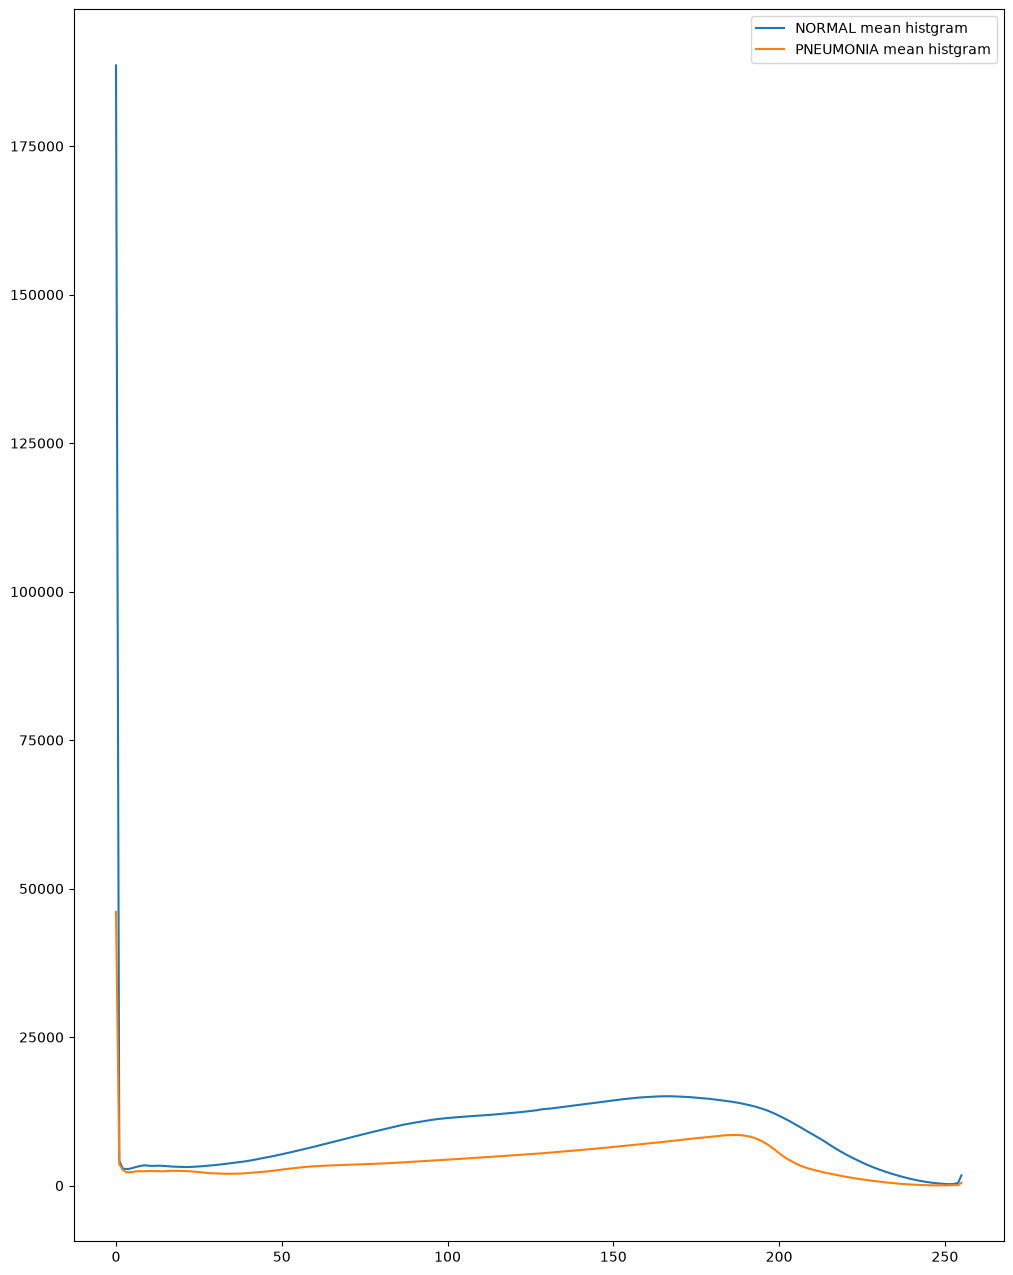

In [232]:
fig ,ax = plt.subplots(figsize=(12,16))

ax.plot(NORMAL_mean_image, label = "NORMAL mean histgram")
ax.plot(PNEUMONIA_mean_image,label = "PNEUMONIA mean histgram")
ax.legend()
plt.show()

PNEUMONIAとNORMALの大きな違いは、0~25の間NORMAL の方が数値は高くなっている。
もう一点は、50付近から200付近まで差が大きいことがわかる。

In [249]:
def check_broken_file(kind , species):
    count = 0
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            image =Image.open(p)
            try:
                pixels = image.load()
            except:
                count += 1

    return print(f"{kind}/{species}の破損ファイルは{count}個です。")

In [250]:
check_broken_file("train" , "PNEUMONIA")

train/PNEUMONIAの破損ファイルは0個です。


In [251]:
check_broken_file("train" , "NORMAL")

train/NORMALの破損ファイルは0個です。


In [252]:
check_broken_file("test" , "NORMAL")

test/NORMALの破損ファイルは0個です。


In [253]:
check_broken_file("test" , "PNEUMONIA")

test/PNEUMONIAの破損ファイルは0個です。


In [254]:
check_broken_file("val" , "PNEUMONIA")

val/PNEUMONIAの破損ファイルは0個です。


In [255]:
check_broken_file("val" , "NORMAL")

val/NORMALの破損ファイルは0個です。


読み込み失敗による破損ファイルの数は0個であった。

In [280]:
# PNEUMONIA train の高さ127の画像を確認する
def get_min_height():
    path_list = []
    path = Path("./data/train/PNEUMONIA/")
    for p in Path.iterdir(path):
        if p.is_file():
            with Image.open(p) as image:
                widrh , height = image.size
                if height == 127:
                    print(p)
    return None

In [281]:
path = get_min_height()

data/train/PNEUMONIA/person407_virus_811.jpeg


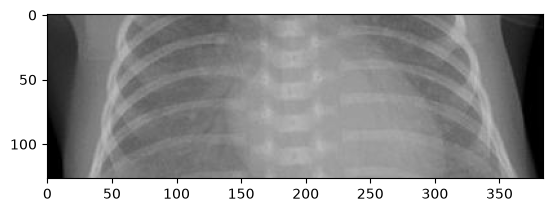

In [284]:
image = Image.open("data/train/PNEUMONIA/person407_virus_811.jpeg")
plt.imshow(image,cmap= "gray")
plt.show()

縦横比が極端で、全体の画像が見えにく画像になっている。

### STEP2 Augmentation

In [289]:
import torchvision.transforms as transforms

In [ ]:
#train全体の平均と標準偏差を求める
# a :頻度　 b : 値
b =np.arange(256)

a = NORMAL_sum_image  +PNEUMONIA_sum_image

In [308]:
add_mean= np.sum(a *b) / np.sum(a)

In [309]:
add_mean

np.float64(124.30439268529355)

In [316]:
add_var= np.sum((b  - add_mean)**2 * a ) / np.sum(a)

In [317]:
add_std =add_var **(0.5)

In [318]:
add_std

np.float64(62.62273995946972)

In [321]:
norm_mean = add_mean / 255
norm_std = add_std / 255

In [ ]:
transfromers = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(),transforms.Normalize((norm_mean ,norm_mean,norm_mean), (norm_std,norm_std,norm_std))])

In [331]:
def Make_Pipeline_data(kind,species):
    image_list = []
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            image = Image.open(p).convert("RGB")
            image_resized = transfromers(image)
            image_list.append(image_resized)
    return image_list


In [339]:
val_NORMAL_list = Make_Pipeline_data("val", "NORMAL")

In [340]:
val_PNEUMONIA_list = Make_Pipeline_data("val", "PNEUMONIA")

In [341]:
test_NORMAL_list = Make_Pipeline_data("test", "NORMAL")

In [342]:
test_PNEUMONIA_list = Make_Pipeline_data("test", "PNEUMONIA")

In [344]:
print(len(val_NORMAL_list))

8


In [345]:
print(len(val_PNEUMONIA_list))

8


In [347]:
print((val_NORMAL_list[0].shape))

torch.Size([3, 224, 224])


In [348]:
print(len(test_NORMAL_list))


234


In [349]:
print(len(test_PNEUMONIA_list))

390


In [350]:
print(test_PNEUMONIA_list[0].shape)

torch.Size([3, 224, 224])


In [351]:
print(test_NORMAL_list[0].shape)

torch.Size([3, 224, 224])


In [363]:
# 左右反転あり
train_transfromers_rotation = transforms.Compose([transforms.Resize((224,224)),
transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),transforms.RandomHorizontalFlip(p=0.5), 
transforms.ColorJitter(brightness=0.1, contrast=0.1),
transforms.ToTensor(),transforms.Normalize((norm_mean ,norm_mean,norm_mean), (norm_std,norm_std,norm_std))])

# 左右反転なし
train_transfromers  = transforms.Compose([transforms.Resize((224,224)),transforms.RandomAffine(degrees=10, 
translate=(0.1, 0.1), scale=(0.9, 1.1)),transforms.ColorJitter(brightness=0.1, contrast=0.1),
 transforms.ToTensor(),transforms.Normalize((norm_mean ,norm_mean,norm_mean), (norm_std,norm_std,norm_std))])

In [364]:
def Make_Pipeline_train_data(kind,species,select_transforms):
    image_list = []
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            image = Image.open(p).convert("RGB")
            image_resized = select_transforms(image)
            image_list.append(image_resized)
    return image_list

In [367]:
train_NORMAL_list= Make_Pipeline_train_data("train" , "NORMAL",train_transfromers)

In [368]:
train_NORMAL_list

[tensor([[[-1.8253, -1.8413, -1.8572,  ..., -1.9850, -1.9850, -1.9850],
          [-1.8572, -1.8732, -1.8892,  ..., -1.9850, -1.9850, -1.9850],
          [-1.8892, -1.9051, -1.9211,  ..., -1.9850, -1.9850, -1.9850],
          ...,
          [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
          [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
          [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850]],
 
         [[-1.8253, -1.8413, -1.8572,  ..., -1.9850, -1.9850, -1.9850],
          [-1.8572, -1.8732, -1.8892,  ..., -1.9850, -1.9850, -1.9850],
          [-1.8892, -1.9051, -1.9211,  ..., -1.9850, -1.9850, -1.9850],
          ...,
          [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
          [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
          [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850]],
 
         [[-1.8253, -1.8413, -1.8572,  ..., -1.9850, -1.9850, -1.9850],
          [-1.8572, -1.8732,

In [370]:
train_PNEUMONIA_list= Make_Pipeline_train_data("train" , "PNEUMONIA",train_transfromers)

In [372]:
print(len(train_NORMAL_list))

1341


In [373]:
print(len(train_PNEUMONIA_list))

3875


In [374]:
print(train_NORMAL_list[0].shape)

torch.Size([3, 224, 224])


In [375]:
print(train_PNEUMONIA_list[0].shape)

torch.Size([3, 224, 224])


## 3 モデル実装

In [379]:
def Make_dataset(kind):
    path_NORMAL_list = []
    path_PNEUMONIA_list =[]
    species = "NORMAL"
    labels = 0
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            path_NORMAL_list.append(p)
            df_NORMAL = pd.DataFrame({
                "label": labels , 
                "path" : path_NORMAL_list,
            })
    species = "PNEUMONIA"  
    labels = 1
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            path_PNEUMONIA_list.append(p)
            df_PNEUMONIA = pd.DataFrame({
                "label": labels,
                "path" : path_PNEUMONIA_list
            })
    df = pd.concat([df_NORMAL,df_PNEUMONIA])
    return df

In [380]:
df = Make_dataset("train")

In [381]:
df

,label,path
0,0,data/train/NORMAL/NORMAL2-IM-0927-0001.jpeg
1,0,data/train/NORMAL/NORMAL2-IM-1056-0001.jpeg
2,0,data/train/NORMAL/IM-0427-0001.jpeg
3,0,data/train/NORMAL/NORMAL2-IM-1260-0001.jpeg
4,0,data/train/NORMAL/IM-0656-0001-0001.jpeg
...,...,...
3870,1,data/train/PNEUMONIA/person142_virus_288.jpeg
3871,1,data/train/PNEUMONIA/person364_bacteria_1659.jpeg
3872,1,data/train/PNEUMONIA/person1323_virus_2283.jpeg
3873,1,data/train/PNEUMONIA/person772_virus_1401.jpeg


In [382]:
len(df)

5216

In [389]:
df["label"].value_counts()

label
1    3875
0    1341
Name: count, dtype: int64

In [391]:
from torch.utils.data import Dataset